# 1. Import libraries

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.style.use("ggplot")

# 2. Load processed data

In [62]:
X_train = pd.read_csv("../data/processed/X_train.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (19929, 55)
y_train shape: (19929,)


# 3. Standardization

In [63]:
scaler = joblib.load("../models/scaler.pkl")

X_scaled = scaler.transform(X_train)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (19929, 55)


# 4. PCA

In [64]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("PCA shape:", X_pca.shape)

Original number of features: 55
PCA shape: (19929, 2)


# 5. PCA Projection

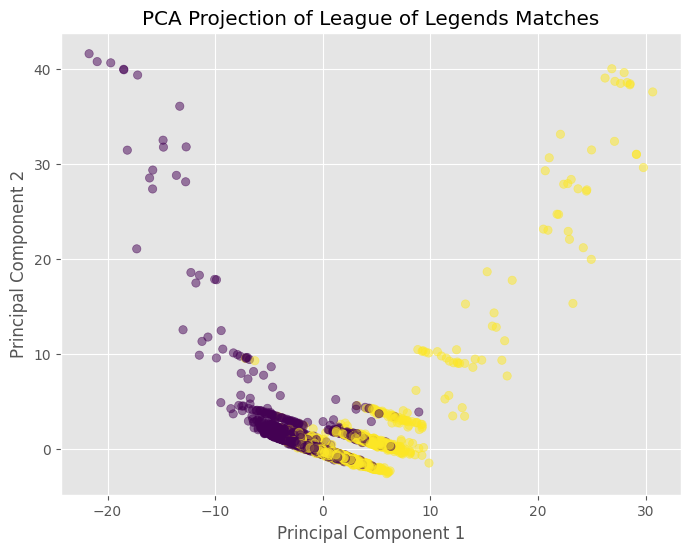

In [65]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_train,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of League of Legends Matches")

plt.show()

# 6. Explained variance

In [66]:
explained_variance = pca.explained_variance_ratio_

print("Explained variance:")
print("PC1:", explained_variance[0])
print("PC2:", explained_variance[1])

print("Total explained variance:", explained_variance.sum())

Explained variance:
PC1: 0.1021170533477132
PC2: 0.07291023529071285
Total explained variance: 0.17502728863842604


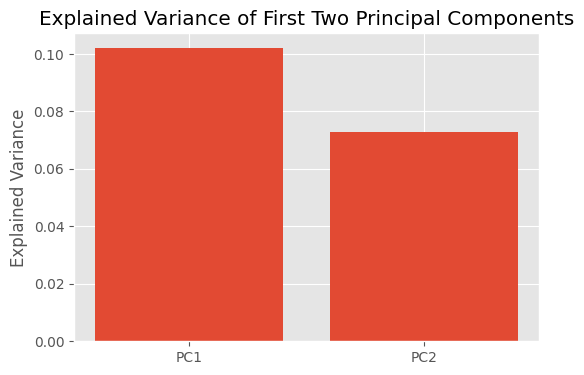

In [67]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["PC1", "PC2"],
    explained_variance
)

plt.ylabel("Explained Variance")
plt.title("Explained Variance of First Two Principal Components")

plt.show()

# 7. Cumulative Explained Variance

In [68]:
pca_full = PCA()

pca_full.fit(X_scaled)

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()

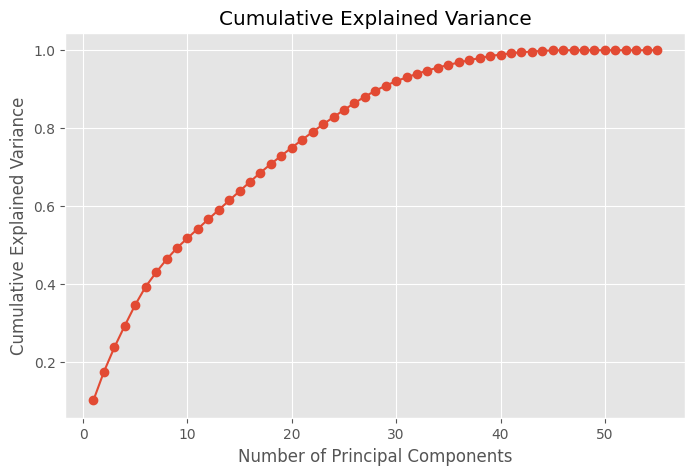

In [69]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.show()

# 8. K-Means clustering

In [70]:
silhouette_scores = []

for k in range(2, 7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        cluster_labels
    )

    silhouette_scores.append(score)

    print(f"k={k}: Silhouette Score={score:.4f}")

k=2: Silhouette Score=0.1004
k=3: Silhouette Score=0.1010
k=4: Silhouette Score=0.1019
k=5: Silhouette Score=0.1021
k=6: Silhouette Score=0.1006


# 9. Silhouette Score comparison

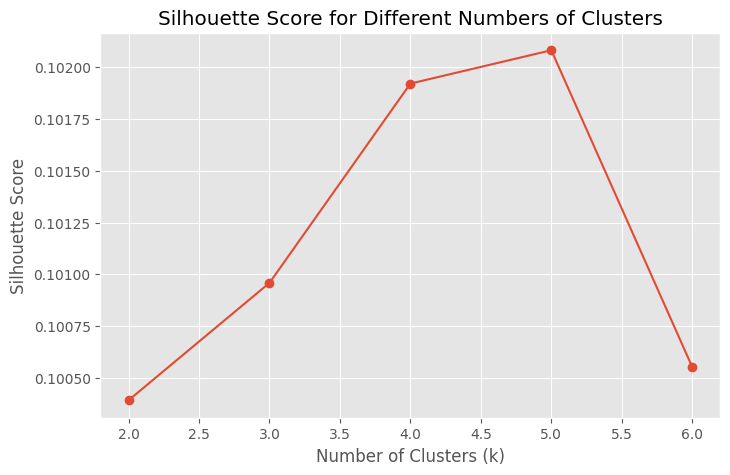

In [71]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 7),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Numbers of Clusters")

plt.show()

In [72]:
best_k = range(2, 7)[silhouette_scores.index(max(silhouette_scores))]

print("Best number of clusters:", best_k)
print("Best Silhouette Score:", max(silhouette_scores))

Best number of clusters: 5
Best Silhouette Score: 0.10208113577270922


# 10. Final K-Means Model

In [73]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# 11. Visualize clusters

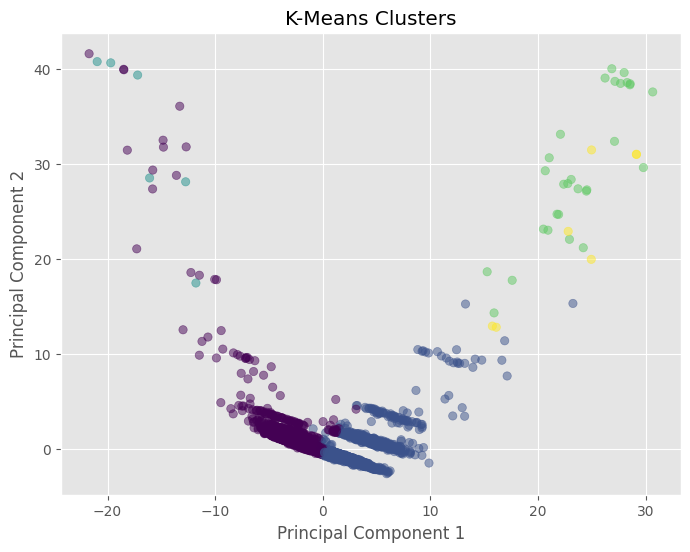

In [74]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters")

plt.show()

# 12. Cluster vs Match Outcome

In [75]:
cluster_df = pd.DataFrame({
    "Cluster": clusters,
    "Won": y_train
})

cluster_outcome = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Won"],
    normalize="index"
)

cluster_outcome

Won,0,1
Cluster,,
0,0.701986,0.298014
1,0.274409,0.725591
2,1.000000,0.000000
3,0.000000,1.000000
4,0.000000,1.000000


In [76]:
cluster_outcome_percent = cluster_outcome * 100

cluster_outcome_percent

Won,0,1
Cluster,,
0,70.198612,29.801388
1,27.440883,72.559117
2,100.000000,0.000000
3,0.000000,100.000000
4,0.000000,100.000000


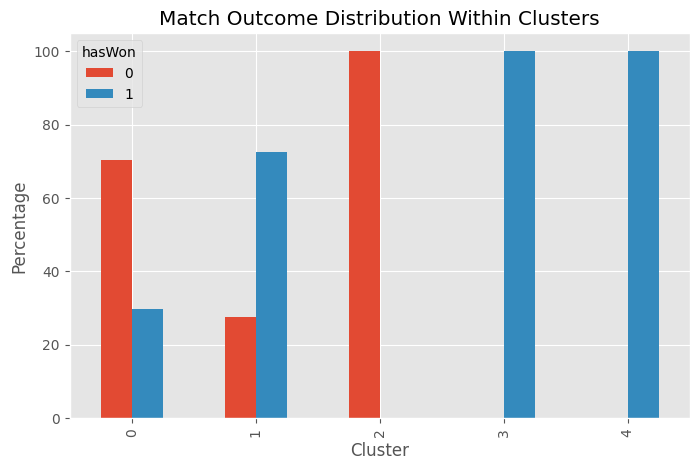

In [77]:
cluster_outcome_percent.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Cluster")
plt.ylabel("Percentage")
plt.title("Match Outcome Distribution Within Clusters")
plt.legend(title="hasWon")

plt.show()

# 13. Conclusions

PCA revealed some structure within the dataset, but the first two principal components explained only about 17.5% of the variation. Therefore, the PCA visualization should primarily be viewed as a simplified representation of the data.

K-Means was used to identify natural groupings in the gameplay data without incorporating match results during training. The Silhouette Score was used to compare different numbers of clusters.

When the clusters were compared with the actual match outcomes, a clear difference in the distribution of winners and losers was observed. This suggests that the gameplay information available after 10 minutes contains structure related to the final match result.

However, clustering is not used as the final prediction model in this project. Instead, the results mainly provide insight into the data and formulate hypotheses for the supervised learning phase.